# View MovieLens 1M Dataset

## 1. Setup - Import the DataLoader

`DataLoader` is a helper class in `src/data_loader.py` that reads the `.dat` files
and returns clean pandas DataFrames. It handles the tricky `::` separator and encoding.

In [3]:
import sys
sys.path.append('..')

from src.data_loader import DataLoader

loader = DataLoader('../dataset/ml-1m')

In [4]:
ratings = loader.load_rating()
movies = loader.load_movies()
users = loader.load_users()

## 3. Ratings
Who rated what. Columns: `user_id`, `movie_id`, `rating` (1-5), `timestamp`.

In [5]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [29]:
ratings.shape

(1000209, 4)

In [30]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


## 4. Movies
Movie metadata. Columns: `movie_id`, `title`, `genre` (pipe-separated).

In [31]:
movies.head()

,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [32]:
movies.shape

(3883, 3)

## 5. Users
User demographics. Columns: `user_id`, `gender`, `age`, `occupation`, `zip_code`.

In [6]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [7]:
users.shape

(6040, 5)

## 6. Quick stats
How many unique users, movies, and ratings?

In [8]:
print(f'Unique users:  {ratings["user_id"].nunique()}')
print(f'Unique movies: {ratings["movie_id"].nunique()}')
print(f'Total ratings: {len(ratings)}')

Unique users:  6040
Unique movies: 3706
Total ratings: 1000209


## 7. Rating distribution
How are the 1-5 star ratings spread?

<Axes: title={'center': 'Rating Distribution'}, xlabel='Rating', ylabel='Count'>

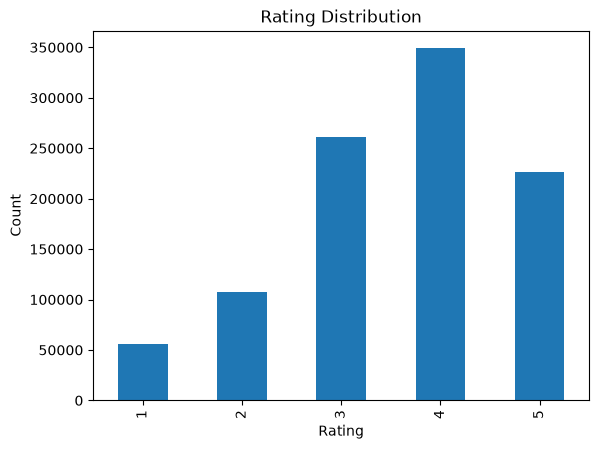

In [9]:
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', title='Rating Distribution', xlabel='Rating', ylabel='Count'
)

## 8. Full merged dataset
`load_full_dataset()` joins all three tables so you can analyze everything together.

In [10]:
full = loader.load_full_dataset()
full.head()

,user_id,movie_id,rating,timestamp,title,genre,gender,age,occupation,zip_code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067


In [11]:
full.shape

(1000209, 10)

## 9. Most rated movies

In [12]:
full.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: rating, dtype: int64

## 10. Highest rated movies (min 50 ratings)

In [13]:
movie_stats = full.groupby('title').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).query('num_ratings >= 50')

movie_stats.sort_values('avg_rating', ascending=False).head(10)

,avg_rating,num_ratings
title,,
Sanjuro (1962),4.608696,69
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954),4.560510,628
"Shawshank Redemption, The (1994)",4.554558,2227
"Godfather, The (1972)",4.524966,2223
"Close Shave, A (1995)",4.520548,657
"Usual Suspects, The (1995)",4.517106,1783
Schindler's List (1993),4.510417,2304
"Wrong Trousers, The (1993)",4.507937,882
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.491489,470
